In [1]:
from datav2 import (
    load_clean,
    validate_data,
    find_outliers,
    verify_relationships)
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
cleaned_dir = Path("PROCESSED")

cleaned_dir.mkdir(parents = True, exist_ok = True)

This help with display of large dataframes.

In [3]:
file_path = Path("basedata/Workobject_1.xlsx").resolve()
df = load_clean(file_path, sheet_name = "Sheet1")



Missing values before cleaning:
Time                    0
X                       0
Y                       0
Z                       0
Z_Adjust                0
q1                      0
q2                      0
q3                      0
q4                      0
Layer                   0
Bead                    0
Actual_Conductance      7
Actual_Power_HotWire    7
Robot_Wire_Speed        0
Pyro_1_Low              0
Pyro_3_High             0
Wire_Speed              0
Laser_Power             0
AI_ProcadaVoltage       0
Control_Z_Send          0
AI_ProcadaCurrent       0
Z_Adj                   0
TCP_Speed               0
MIG_Voltage             0
MIG_Current             0
frame_address           0
Anamoly                 0
dtype: int64


In [4]:
df.head(50)

,Time,X,Y,Z,Z_Adjust,q1,q2,q3,q4,Layer,Bead,Actual_Conductance,Actual_Power_HotWire,Robot_Wire_Speed,Pyro_1_Low,Pyro_3_High,Wire_Speed,Laser_Power,AI_ProcadaVoltage,Control_Z_Send,AI_ProcadaCurrent,Z_Adj,TCP_Speed,MIG_Voltage,MIG_Current,frame_address,Anamoly
0,2024-05-20 08:22:58.996,51.730175,57.361431,14.427384,0.000,0.000237,0.999018,2.645253e-06,0.044311,1,1,31.065735,216.951660,6.0,97.200000,281.20000,2.00,7225.2,2.000,2.889793,2.256000,2.7920,2.000,2.000,2.00,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,No Wire
1,2024-05-20 08:22:59.296,53.900574,57.516422,14.372743,1.556,0.000131,0.999027,-1.816795e-05,0.044100,1,1,31.065735,216.951660,6.0,97.200000,281.20000,3.36,7225.2,2.000,2.889793,2.256000,3.7008,2.000,2.040,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,No Wire
2,2024-05-20 08:22:59.413,55.888733,57.511047,14.932528,2.126,0.000136,0.999025,-3.157036e-05,0.044137,1,1,31.065735,216.951660,6.0,97.200000,716.96001,3.36,7225.2,5.528,3.575984,2.248000,3.7008,2.000,2.040,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,No Wire
3,2024-05-20 08:22:59.538,57.952778,57.414803,15.578164,2.126,0.000172,0.999022,-3.768429e-05,0.044205,1,1,2.056236,3.093680,6.0,97.200000,716.96001,3.36,7225.2,5.528,3.480358,2.248000,3.7008,14.264,2.040,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,No Wire
4,2024-05-20 08:22:59.633,59.033165,57.405104,14.799870,1.703,0.000183,0.999023,-1.991930e-05,0.044203,1,1,2.056236,3.093680,6.0,97.200000,716.96001,6.00,7225.2,5.528,3.480358,2.248000,3.4800,13.984,2.032,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,No Wire
5,2024-05-20 08:22:59.686,60.077553,57.417343,15.640728,1.850,0.000190,0.999022,-2.011076e-05,0.044220,1,1,2.056236,3.093680,6.0,97.200000,716.96001,6.00,7225.2,5.528,3.606458,2.248000,3.4800,14.008,2.032,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,No Wire
6,2024-05-20 08:22:59.822,62.101456,57.322292,15.484404,1.850,0.000230,0.999018,-1.644396e-05,0.044296,1,1,30.485818,217.423999,6.0,97.200000,716.96001,6.00,7225.2,4.200,3.702884,80.335999,3.4800,14.000,2.032,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,Stable
7,2024-05-20 08:22:59.970,64.165756,57.293785,15.226998,1.850,0.000236,0.999018,-2.167065e-05,0.044306,1,1,30.485818,217.423999,6.0,97.200000,716.96001,6.00,7225.2,4.200,3.975179,80.335999,3.7840,14.000,2.032,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,Stable
8,2024-05-20 08:23:00.107,66.237930,57.279190,15.295661,2.230,0.000235,0.999018,-2.816532e-05,0.044300,1,1,31.070590,217.075806,6.0,97.200000,716.96001,6.00,7225.2,4.176,4.166497,81.071997,3.7840,14.032,2.032,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,Stable
9,2024-05-20 08:23:00.241,68.272713,57.289284,15.315438,2.230,0.000246,0.999017,-1.324872e-05,0.044331,1,1,31.070590,217.075806,6.0,128.319995,716.96001,6.00,7225.2,4.176,4.273411,81.071997,3.7840,14.000,2.032,2.08,/project/AM_PostBuild_Analysis/DOE 2/Image dat...,Stable


Validate the data

In [5]:
validate_data(df)


Value range checks:
X:
Min: 51.69, Max: 252.40
Y:
Min: 41.10, Max: 57.56
Z:
Min: 13.81, Max: 125.02
Z_Adjust:
Min: -10.00, Max: 9.41
q1:
Min: 0.00, Max: 0.00
q2:
Min: 1.00, Max: 1.00
q3:
Min: -0.00, Max: 0.00
q4:
Min: 0.04, Max: 0.04
Actual_Conductance:
Min: 2.02, Max: 65.51
Actual_Power_HotWire:
Min: 2.11, Max: 458.11
Robot_Wire_Speed:
Min: 4.80, Max: 7.60
Pyro_1_Low:
Min: 69.20, Max: 470.40
Pyro_3_High:
Min: 281.20, Max: 1174.00
Wire_Speed:
Min: 2.00, Max: 7.62
Laser_Power:
Min: 2.00, Max: 7248.40
AI_ProcadaVoltage:
Min: 2.00, Max: 6.81
Control_Z_Send:
Min: -6.37, Max: 10.61
AI_ProcadaCurrent:
Min: 2.00, Max: 99.10
Z_Adj:
Min: -6.00, Max: 9.70
TCP_Speed:
Min: 2.00, Max: 18.00
MIG_Voltage:
Min: 2.00, Max: 2.06
MIG_Current:
Min: 2.00, Max: 2.08


Find Outliers

In [6]:
numeric_columns = ["X", "Y", "Z", "Laser_Power", "AI_ProcadaCurrent", "MIG_Voltage"]

print("\nNumber of outliers in each column:")
for column in numeric_columns:
    n_outliers = find_outliers(df, column)
    print(f"{column}: {n_outliers} outliers")


Number of outliers in each column:

X bounds:
Lower bound: -54.52
Upper bound: 374.34
IQR: 107.21
X: 0 outliers

Y bounds:
Lower bound: 33.31
Upper bound: 65.37
IQR: 8.01
Y: 0 outliers

Z bounds:
Lower bound: -51.84
Upper bound: 180.86
IQR: 58.18
Z: 0 outliers

Laser_Power bounds:
Lower bound: 7179.20
Upper bound: 7252.80
IQR: 18.40
Laser_Power: 3050 outliers

AI_ProcadaCurrent bounds:
Lower bound: 68.94
Upper bound: 91.32
IQR: 5.60
AI_ProcadaCurrent: 3044 outliers

MIG_Voltage bounds:
Lower bound: 2.03
Upper bound: 2.03
IQR: 0.00
MIG_Voltage: 1852 outliers


In [7]:
# print("\nNumber of outliers in each numeric column:")
# for col in numeric_columns:
#     n_outliers = find_outliers(df, col)
#     if n_outliers > 0:
#         print(f"{col}: {n_outliers} outliers")

In [8]:
numeric_cols = ["Laser_Power", "AI_ProcadaCurrent", "MIG_Voltage"]

for multiplier in [1.5, 2.0, 2.5]:
    print(f"\nTesting with IQR multiplier: {multiplier}")
    for column in numeric_cols:
        n_outliers = find_outliers(df, column, iqr_multiplier=multiplier, show_bounds=True)
        print(f"Number of outliers: {n_outliers}")


Testing with IQR multiplier: 1.5

Laser_Power bounds:
Lower bound: 7179.20
Upper bound: 7252.80
IQR: 18.40
Number of outliers: 3050

AI_ProcadaCurrent bounds:
Lower bound: 68.94
Upper bound: 91.32
IQR: 5.60
Number of outliers: 3044

MIG_Voltage bounds:
Lower bound: 2.03
Upper bound: 2.03
IQR: 0.00
Number of outliers: 1852

Testing with IQR multiplier: 2.0

Laser_Power bounds:
Lower bound: 7170.00
Upper bound: 7262.00
IQR: 18.40
Number of outliers: 3050

AI_ProcadaCurrent bounds:
Lower bound: 66.14
Upper bound: 94.12
IQR: 5.60
Number of outliers: 3024

MIG_Voltage bounds:
Lower bound: 2.03
Upper bound: 2.03
IQR: 0.00
Number of outliers: 1852

Testing with IQR multiplier: 2.5

Laser_Power bounds:
Lower bound: 7160.80
Upper bound: 7271.20
IQR: 18.40
Number of outliers: 3050

AI_ProcadaCurrent bounds:
Lower bound: 63.34
Upper bound: 96.92
IQR: 5.60
Number of outliers: 3004

MIG_Voltage bounds:
Lower bound: 2.03
Upper bound: 2.03
IQR: 0.00
Number of outliers: 1852


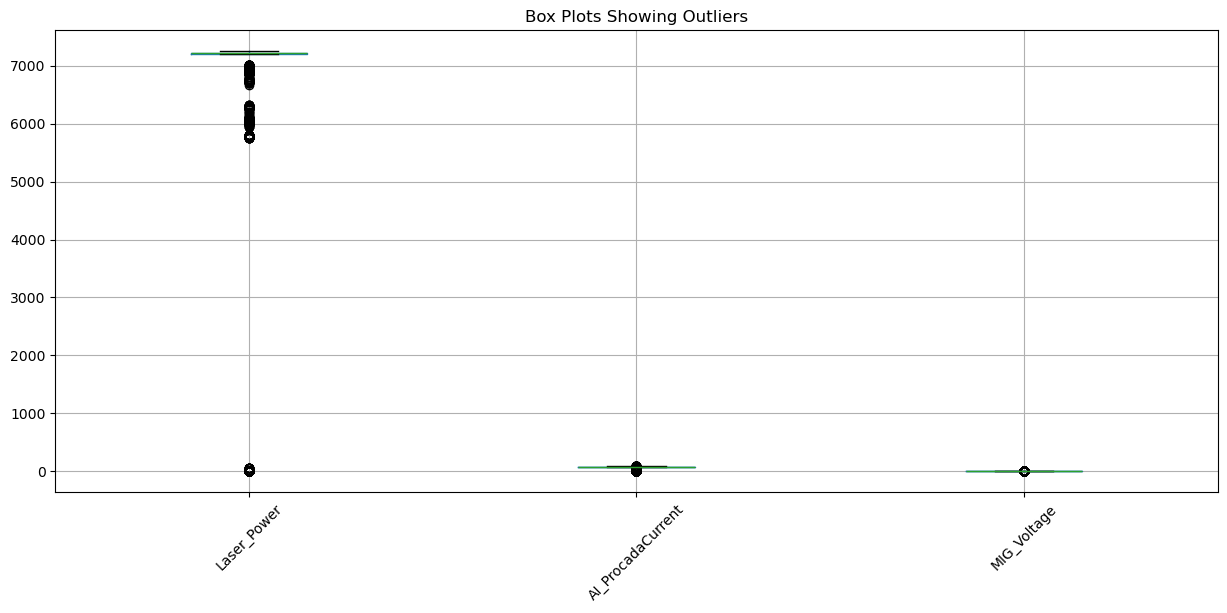

In [9]:
plt.figure(figsize=(15, 6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Box Plots Showing Outliers')
plt.show()

In [10]:
verify_relationships(df)


Correlations between key welding parameters:
                      Actual_Power_HotWire  Robot_Wire_Speed  Wire_Speed  \
Actual_Power_HotWire              1.000000          0.156277    0.260916   
Robot_Wire_Speed                  0.156277          1.000000    0.294384   
Wire_Speed                        0.260916          0.294384    1.000000   
Laser_Power                       0.110437          0.090848    0.716525   
MIG_Current                       0.153119          0.073361    0.811981   
MIG_Voltage                       0.100768          0.073476    0.737500   
AI_ProcadaCurrent                 0.729909          0.183332    0.607889   
AI_ProcadaVoltage                -0.433499         -0.068823    0.425696   

                      Laser_Power  MIG_Current  MIG_Voltage  \
Actual_Power_HotWire     0.110437     0.153119     0.100768   
Robot_Wire_Speed         0.090848     0.073361     0.073476   
Wire_Speed               0.716525     0.811981     0.737500   
Laser_Power      

Save te cleaned data with missing values handled.


In [11]:
file_path = cleaned_dir/"cleaned_wobj_data_v1.csv"
df.to_csv(file_path, index = False)

print(f"Cleaned data saved to {file_path}")

Cleaned data saved to PROCESSED/cleaned_wobj_data_v1.csv
